
Total pares: 2305
Positivos (genuinos): 1900
Negativos (impostores): 405

Ejemplos de scores Coseno y SVM con sus etiquetas:
Label: 1, Score Coseno: 1.000, Score SVM: 0.000
Label: 1, Score Coseno: 1.000, Score SVM: 0.000
Label: 1, Score Coseno: 1.000, Score SVM: 0.000
Label: 1, Score Coseno: 1.000, Score SVM: -0.000
Label: 1, Score Coseno: 1.000, Score SVM: 0.000
EER calculado en índice 1: FPR=0.580, FNR=0.321, EER=0.451
EER calculado en índice 166: FPR=0.022, FNR=0.000, EER=0.011

Puntos iniciales de la curva ROC Coseno:
FPR: 0.000, TPR: 0.000
FPR: 0.580, TPR: 0.679
FPR: 0.879, TPR: 0.911
FPR: 0.973, TPR: 0.989
FPR: 1.000, TPR: 0.998

Puntos iniciales de la curva ROC SVM:
FPR: 0.000, TPR: 0.000
FPR: 0.000, TPR: 0.001
FPR: 0.000, TPR: 0.002
FPR: 0.000, TPR: 0.003
FPR: 0.000, TPR: 0.004

Resultados:
Coseno - AUC: 0.551, EER: 45.065%
SVM    - AUC: 0.984, EER: 1.111%


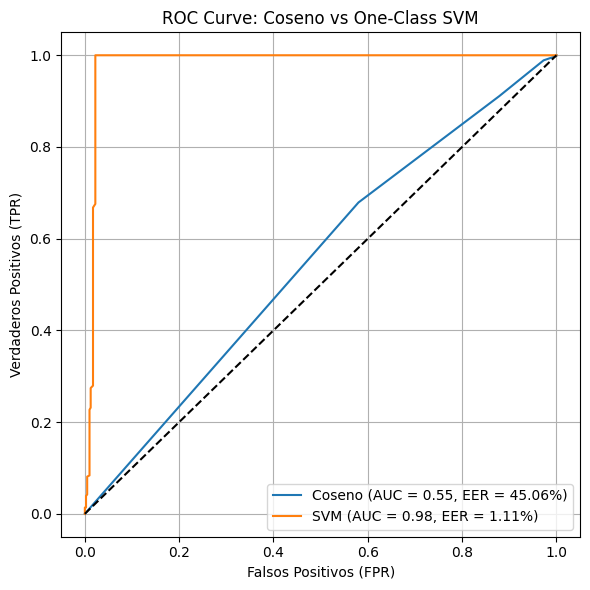

In [6]:
import os
import sys
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from itertools import combinations
from scipy.spatial.distance import cosine
sys.path.append(os.path.abspath(".."))
from asv import compute_vocal_fingerprint

# Función para calcular el Equal Error Rate con prints
def compute_eer(fpr, tpr):
    fnr = 1 - tpr
    abs_diffs = np.abs(fpr - fnr)
    idx = np.argmin(abs_diffs)
    eer = (fpr[idx] + fnr[idx]) / 2
    print(f"EER calculado en índice {idx}: FPR={fpr[idx]:.3f}, FNR={fnr[idx]:.3f}, EER={eer:.3f}")
    return eer

# --- Configuración ---
AUDIO_DIR = "es"
MODEL_DIR = "models"

# 1. Cargar todas las huellas por usuario
usuarios = sorted(os.listdir(AUDIO_DIR))
huellas_por_usuario = {}

for user in usuarios:
    user_path = os.path.join(AUDIO_DIR, user)
    if not os.path.isdir(user_path): continue

    wavs = sorted([
        f for f in os.listdir(user_path)
        if f.endswith(".wav")
    ])[:20]  # Limita a 20 por usuario

    huellas = []
    for wav in wavs:
        path = os.path.join(user_path, wav)
        fp = compute_vocal_fingerprint(path)
        if fp is not None:
            huellas.append(fp)
    if len(huellas) >= 5:
        huellas_por_usuario[user] = huellas

# 2. Generar pares genuinos e impostores
pares = []
labels = []

for usuario, huellas in huellas_por_usuario.items():
    for fp1, fp2 in combinations(huellas, 2):
        pares.append((fp1, fp2, usuario))
        labels.append(1)

usuarios_disponibles = list(huellas_por_usuario.keys())
for i in range(len(usuarios_disponibles)):
    for j in range(i+1, len(usuarios_disponibles)):
        u1 = usuarios_disponibles[i]
        u2 = usuarios_disponibles[j]
        for fp1 in huellas_por_usuario[u1][:3]:
            for fp2 in huellas_por_usuario[u2][:3]:
                pares.append((fp1, fp2, u1))
                labels.append(0)

print(f"\nTotal pares: {len(pares)}")
print(f"Positivos (genuinos): {sum(labels)}")
print(f"Negativos (impostores): {len(labels) - sum(labels)}")

# 3. Calcular scores
scores_cos = []
scores_svm = []

for fp1, fp2, user_id in pares:
    # Coseno
    score_cos = 1 - cosine(fp1, fp2)
    scores_cos.append(score_cos)

    # SVM
    model_path = os.path.join(MODEL_DIR, f"{user_id}_svm.pkl")
    if os.path.exists(model_path):
        scaler = joblib.load(os.path.join(MODEL_DIR, f"{user_id}_scaler.pkl"))
        model = joblib.load(os.path.join(MODEL_DIR, f"{user_id}_svm.pkl"))

        fp1_scaled = scaler.transform(fp1.reshape(1, -1))
        fp2_scaled = scaler.transform(fp2.reshape(1, -1))
        
        score1 = model.decision_function(fp1_scaled)[0]
        score2 = model.decision_function(fp2_scaled)[0]
        score_svm = min(score1, score2)  # o también: (score1 + score2) / 2
    else:
        score_svm = score_cos
    scores_svm.append(score_svm)

print("\nEjemplos de scores Coseno y SVM con sus etiquetas:")
for i in range(5):
    print(f"Label: {labels[i]}, Score Coseno: {scores_cos[i]:.3f}, Score SVM: {scores_svm[i]:.3f}")

# 4. ROC, AUC y EER
fpr_cos, tpr_cos, _ = roc_curve(labels, scores_cos)
auc_cos = auc(fpr_cos, tpr_cos)
eer_cos = compute_eer(fpr_cos, tpr_cos)

fpr_svm, tpr_svm, _ = roc_curve(labels, scores_svm)
auc_svm = auc(fpr_svm, tpr_svm)
eer_svm = compute_eer(fpr_svm, tpr_svm)

print("\nPuntos iniciales de la curva ROC Coseno:")
for i in range(min(5, len(fpr_cos))):
    print(f"FPR: {fpr_cos[i]:.3f}, TPR: {tpr_cos[i]:.3f}")

print("\nPuntos iniciales de la curva ROC SVM:")
for i in range(min(5, len(fpr_svm))):
    print(f"FPR: {fpr_svm[i]:.3f}, TPR: {tpr_svm[i]:.3f}")

print(f"\nResultados:")
print(f"Coseno - AUC: {auc_cos:.3f}, EER: {eer_cos:.3%}")
print(f"SVM    - AUC: {auc_svm:.3f}, EER: {eer_svm:.3%}")

# 5. Mostrar resultados
plt.figure(figsize=(6,6))
plt.plot(fpr_cos, tpr_cos, label=f"Coseno (AUC = {auc_cos:.2f}, EER = {eer_cos:.2%})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f}, EER = {eer_svm:.2%})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("Falsos Positivos (FPR)")
plt.ylabel("Verdaderos Positivos (TPR)")
plt.title("ROC Curve: Coseno vs One-Class SVM")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
